In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df = pd.read_csv('Customer Churn.csv')
df.head()

,Column1,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Column1           7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Replacing Blank With 0 as tenure is 0 and no total charges are recorded & Change The Data type Object to float 

In [5]:
df['TotalCharges'] = df['TotalCharges'].replace(" " , 0) 
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
def conv(value):
    if value == 1:
        return "Yes"
    else:
        return "No"

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

    

## Converted 0 and 1 Value Of Senior Citizen to Yes/No to make it easier to understand 

In [10]:
df.head()

,Column1,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


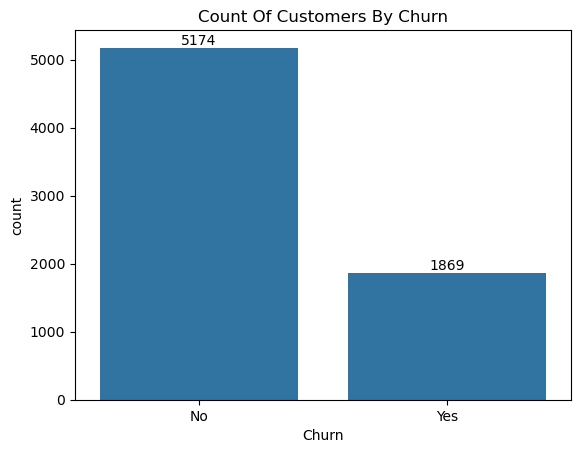

In [11]:
lp = sns.countplot(x= 'Churn' , data = df)

lp.bar_label(lp.containers[0])
plt.title('Count Of Customers By Churn')
plt.show()

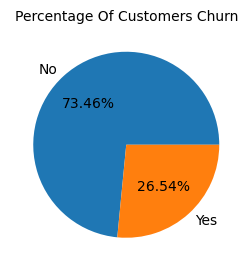

In [12]:
plt.figure(figsize  = (3,4))
gb = df.groupby("Churn").agg({"Churn":"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%" )
plt.title('Percentage Of Customers Churn', fontsize = 10)
plt.show()

## From The Given Pie Chart We Can Conclude That 26.54 % Of Customers Are Churn Out Now Let Find Out Reason Behind it 

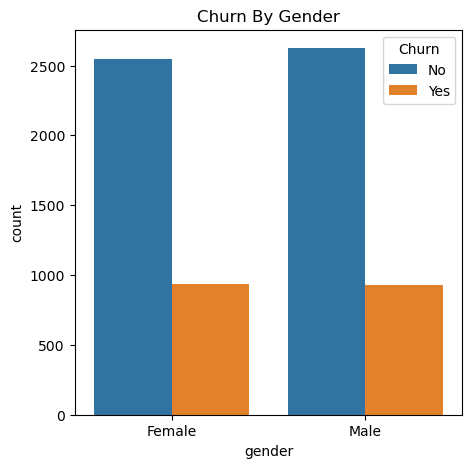

In [13]:
plt.figure(figsize = (5,5))
sns.countplot(x = "gender" , data = df, hue= 'Churn')
plt.title("Churn By Gender")
plt.show()

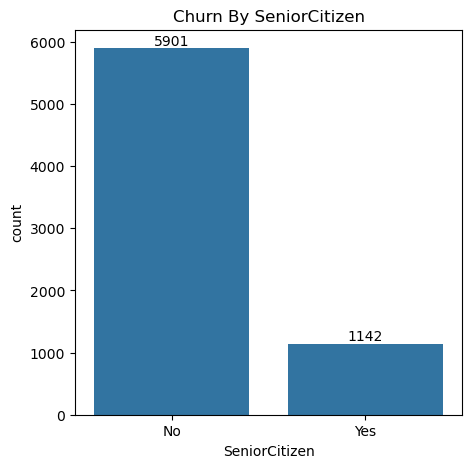

In [14]:
plt.figure(figsize = (5,5))
lp = sns.countplot(x="SeniorCitizen" , data = df)
lp.bar_label(lp.containers[0])
plt.title("Churn By SeniorCitizen") 
plt.show()

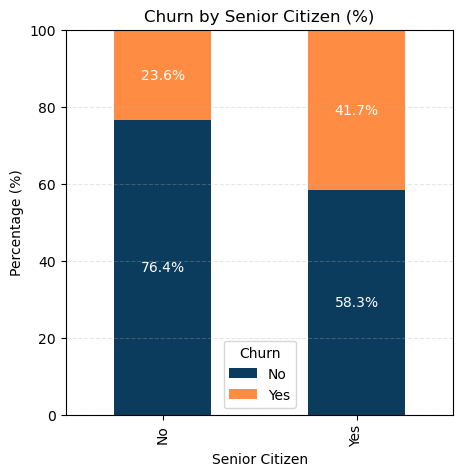

In [15]:

data = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

ax = data.plot(kind='bar', stacked=True, figsize=(5,5),
               color=['#0B3C5D', '#FF8C42'])

for c in ax.containers:
    ax.bar_label(c,
                 labels=[f'{v:.1f}%' if v > 0 else '' for v in c.datavalues],
                 label_type='center',
                 color='white',
                 fontsize=10)

plt.title('Churn by Senior Citizen (%)')
plt.xlabel('Senior Citizen')
plt.ylabel('Percentage (%)')
plt.ylim(0,100)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## Comparatively A Greater Percentage OF Prople In Senior Citizen Category Have Churned

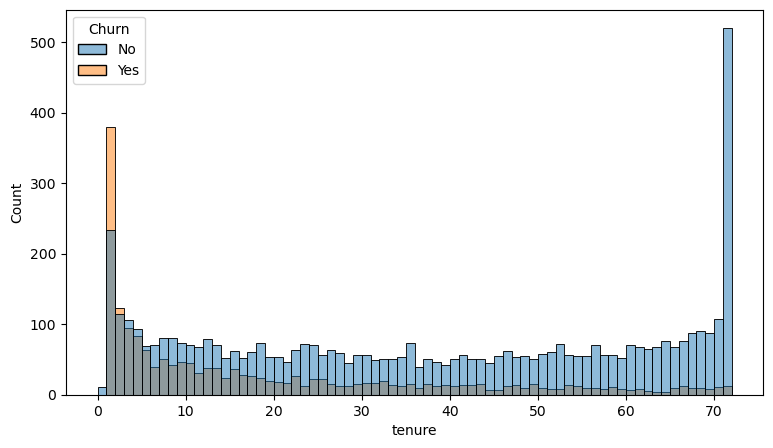

In [16]:
plt.figure(figsize = (9,5))
sns.histplot(x='tenure', data = df, bins=72, hue = 'Churn')
plt.show()

## Pleople Who have used Our Services For A Long Time Have Stayed and Prople Who Have Used Our Services For 1 Or 2 Months Have Churned  

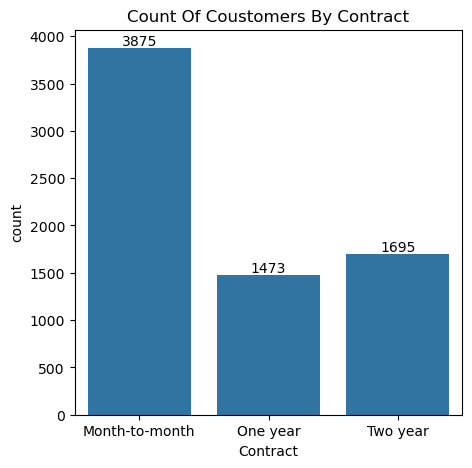

In [17]:
plt.figure(figsize=(5,5))
lp = sns.countplot(x= 'Contract', data = df)
lp.bar_label(lp.containers[0])
plt.title("Count Of Coustomers By Contract")
plt.show()


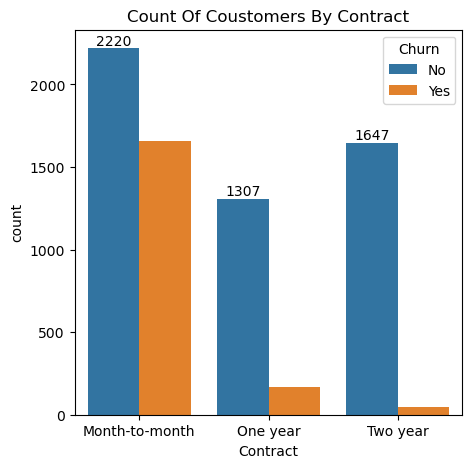

In [18]:
plt.figure(figsize=(5,5))
lp = sns.countplot(x= 'Contract', data = df, hue= 'Churn')
lp.bar_label(lp.containers[0])
plt.title("Count Of Coustomers By Contract")
plt.show()


## People Who Have Month To Month Contarct Are Likely To Churn Then From Those Who Have 1 Or 2 Years Of Contarct 

In [20]:
df.columns.values

array(['Column1', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

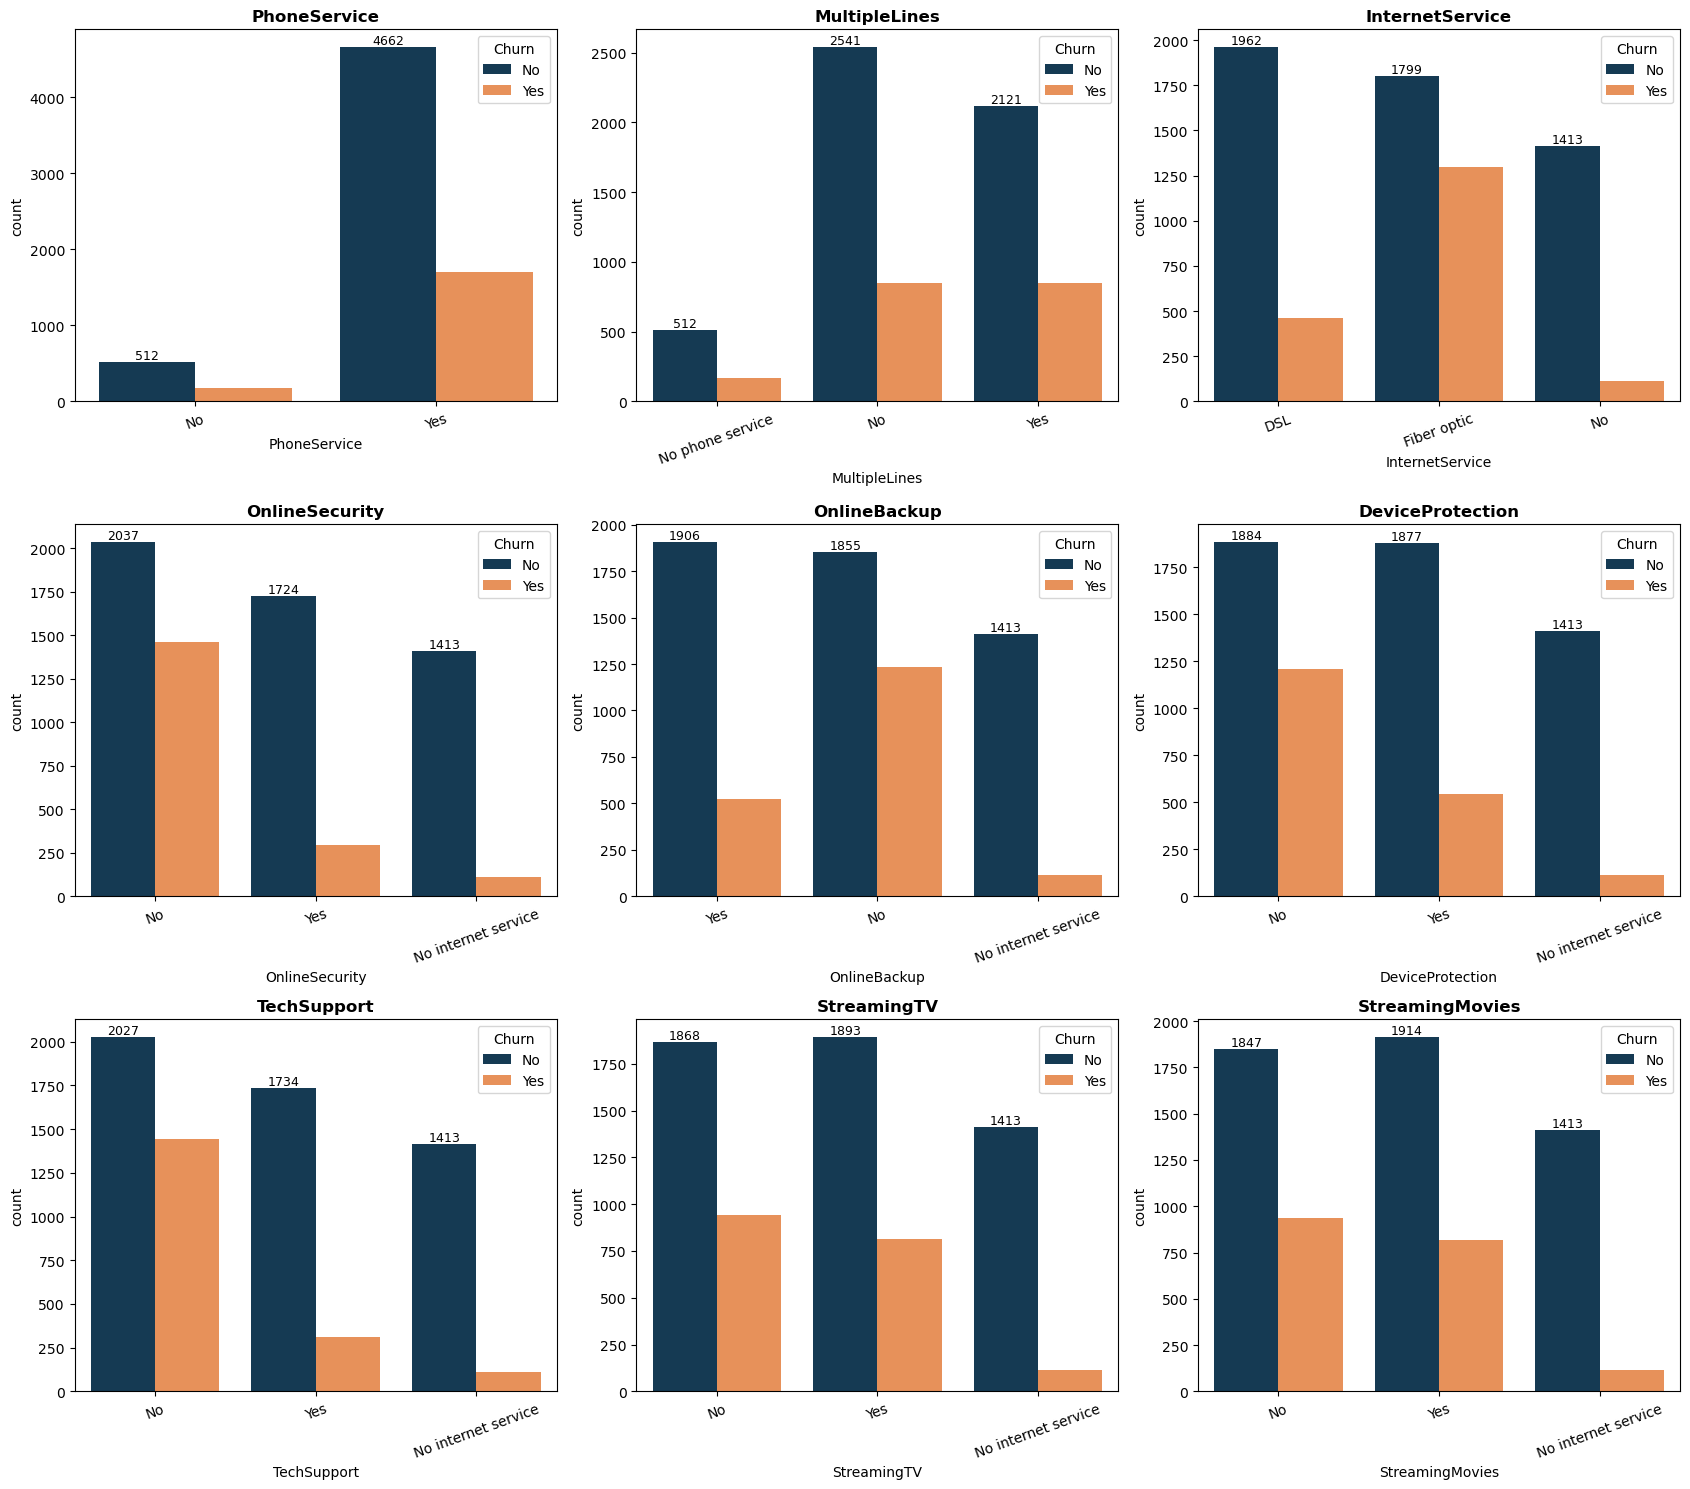

In [29]:
import warnings
warnings.filterwarnings("ignore")

cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(17, 15))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = sns.countplot(data=df, x=col, ax=axes[i],  palette=['#0B3C5D', '#FF8C42'], hue ="Churn")
    ax.bar_label(ax.containers[0], fontsize=9)
    ax.set_title(col, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## The visualizations indicate that customers without value-added services such as Online Security, Tech Support, and Device Protection exhibit significantly higher churn rates compared to those who subscribe to these services. Customers using Fiber Optic Internet also show a noticeably higher likelihood of churn than those with DSL or no internet service. In contrast, features like Phone Service, Streaming TV, and Streaming Movies appear to have a relatively weaker influence on customer churn. Overall, internet-related services and customer support offerings are the strongest factors associated with customer retention.

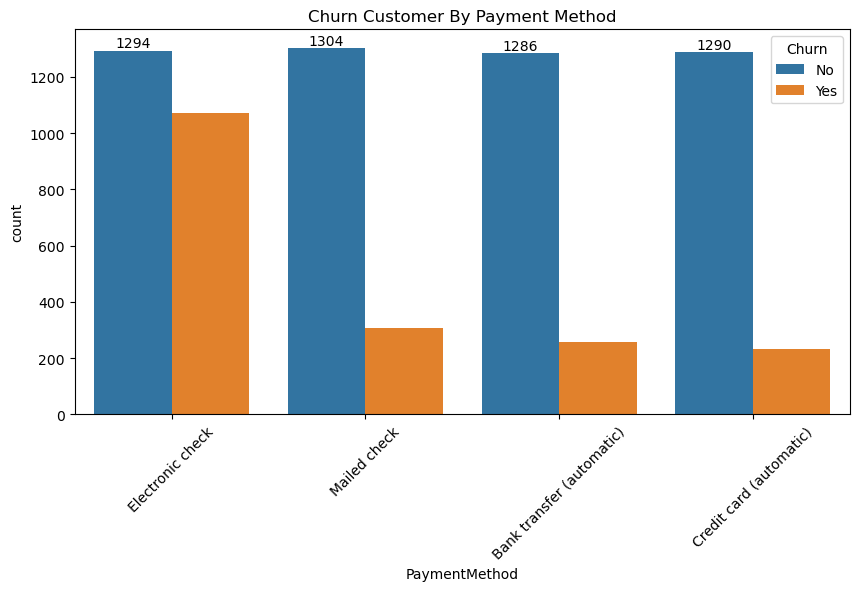

In [41]:
plt.figure(figsize= (10,5))
lp = sns.countplot( x= "PaymentMethod" , data = df, hue="Churn")
lp.bar_label(lp.containers[0])
plt.title("Churn Customer By Payment Method")
plt.xticks(rotation = 45)
plt.show()

## The analysis shows that customers using Electronic Check have the highest churn rate compared to all other payment methods. Customers who pay through Bank Transfer (Automatic) or Credit Card (Automatic) exhibit significantly lower churn, indicating better customer retention. Mailed Check users have a moderate churn rate, falling between electronic and automatic payment methods. Overall, automatic payment options are associated with improved customer retention and lower churn.